# Proyek Analisis Data (E-Commerce Public Dataset)

- **Nama:** Salman Al Farizi Harahap
- **Email:** m315b4ky4024@bangkit.academy
- **ID Dicoding:** salman_al_farizi_harahap_Yv6N

## Menentukan Pertanyaan Bisnis

1. How's the performance of the sales a few months ago?
2. What item sales the most and the least?
3. How is the performance of our packaging time and shipping time?

## Import Semua Packages/Library yang Digunakan

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import geopandas as gpd

## Data Wrangling

As I complete the module about data wrangling, now I have to do some exercise to let my knowledge from the module flow

### Gathering Data

The first think I have to do is get the data. The data provides by Dicoding with 4 kinds of dataset. Here's the [link](https://github.com/dicodingacademy/dicoding_dataset/tree/main/DicodingCollection) of the datasets.

So now I have the dataset and ready to use in this notebook.

In [2]:
customer_df = pd.read_csv("data/customers_dataset.csv")
customer_df

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP
...,...,...,...,...,...
99436,17ddf5dd5d51696bb3d7c6291687be6f,1a29b476fee25c95fbafc67c5ac95cf8,3937,sao paulo,SP
99437,e7b71a9017aa05c9a7fd292d714858e8,d52a67c98be1cf6a5c84435bd38d095d,6764,taboao da serra,SP
99438,5e28dfe12db7fb50a4b2f691faecea5e,e9f50caf99f032f0bf3c55141f019d99,60115,fortaleza,CE
99439,56b18e2166679b8a959d72dd06da27f9,73c2643a0a458b49f58cea58833b192e,92120,canoas,RS


In [3]:
geolocation_df = pd.read_csv("data/geolocation_dataset.csv")
geolocation_df

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,1037,-23.545621,-46.639292,sao paulo,SP
1,1046,-23.546081,-46.644820,sao paulo,SP
2,1046,-23.546129,-46.642951,sao paulo,SP
3,1041,-23.544392,-46.639499,sao paulo,SP
4,1035,-23.541578,-46.641607,sao paulo,SP
...,...,...,...,...,...
1000158,99950,-28.068639,-52.010705,tapejara,RS
1000159,99900,-27.877125,-52.224882,getulio vargas,RS
1000160,99950,-28.071855,-52.014716,tapejara,RS
1000161,99980,-28.388932,-51.846871,david canabarro,RS


In [4]:
order_items_df = pd.read_csv("data/order_items_dataset.csv")
order_items_df

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14
...,...,...,...,...,...,...,...
112645,fffc94f6ce00a00581880bf54a75a037,1,4aa6014eceb682077f9dc4bffebc05b0,b8bc237ba3788b23da09c0f1f3a3288c,2018-05-02 04:11:01,299.99,43.41
112646,fffcd46ef2263f404302a634eb57f7eb,1,32e07fd915822b0765e448c4dd74c828,f3c38ab652836d21de61fb8314b69182,2018-07-20 04:31:48,350.00,36.53
112647,fffce4705a9662cd70adb13d4a31832d,1,72a30483855e2eafc67aee5dc2560482,c3cfdc648177fdbbbb35635a37472c53,2017-10-30 17:14:25,99.90,16.95
112648,fffe18544ffabc95dfada21779c9644f,1,9c422a519119dcad7575db5af1ba540e,2b3e4a2a3ea8e01938cabda2a3e5cc79,2017-08-21 00:04:32,55.99,8.72


In [5]:
order_payments_df = pd.read_csv("data/order_payments_dataset.csv")
order_payments_df

,order_id,payment_sequential,payment_type,payment_installments,payment_value
0,b81ef226f3fe1789b1e8b2acac839d17,1,credit_card,8,99.33
1,a9810da82917af2d9aefd1278f1dcfa0,1,credit_card,1,24.39
2,25e8ea4e93396b6fa0d3dd708e76c1bd,1,credit_card,1,65.71
3,ba78997921bbcdc1373bb41e913ab953,1,credit_card,8,107.78
4,42fdf880ba16b47b59251dd489d4441a,1,credit_card,2,128.45
...,...,...,...,...,...
103881,0406037ad97740d563a178ecc7a2075c,1,boleto,1,363.31
103882,7b905861d7c825891d6347454ea7863f,1,credit_card,2,96.80
103883,32609bbb3dd69b3c066a6860554a77bf,1,credit_card,1,47.77
103884,b8b61059626efa996a60be9bb9320e10,1,credit_card,5,369.54


In [6]:
order_reviews_df = pd.read_csv("data/order_reviews_dataset.csv")
order_reviews_df

,review_id,order_id,review_score,review_comment_title,review_comment_message,review_creation_date,review_answer_timestamp
0,7bc2406110b926393aa56f80a40eba40,73fc7af87114b39712e6da79b0a377eb,4,NaN,NaN,2018-01-18 00:00:00,2018-01-18 21:46:59
1,80e641a11e56f04c1ad469d5645fdfde,a548910a1c6147796b98fdf73dbeba33,5,NaN,NaN,2018-03-10 00:00:00,2018-03-11 03:05:13
2,228ce5500dc1d8e020d8d1322874b6f0,f9e4b658b201a9f2ecdecbb34bed034b,5,NaN,NaN,2018-02-17 00:00:00,2018-02-18 14:36:24
3,e64fb393e7b32834bb789ff8bb30750e,658677c97b385a9be170737859d3511b,5,NaN,Recebi bem antes do prazo estipulado.,2017-04-21 00:00:00,2017-04-21 22:02:06
4,f7c4243c7fe1938f181bec41a392bdeb,8e6bfb81e283fa7e4f11123a3fb894f1,5,NaN,Parabéns lojas lannister adorei comprar pela I...,2018-03-01 00:00:00,2018-03-02 10:26:53
...,...,...,...,...,...,...,...
99219,574ed12dd733e5fa530cfd4bbf39d7c9,2a8c23fee101d4d5662fa670396eb8da,5,NaN,NaN,2018-07-07 00:00:00,2018-07-14 17:18:30
99220,f3897127253a9592a73be9bdfdf4ed7a,22ec9f0669f784db00fa86d035cf8602,5,NaN,NaN,2017-12-09 00:00:00,2017-12-11 20:06:42
99221,b3de70c89b1510c4cd3d0649fd302472,55d4004744368f5571d1f590031933e4,5,NaN,"Excelente mochila, entrega super rápida. Super...",2018-03-22 00:00:00,2018-03-23 09:10:43
99222,1adeb9d84d72fe4e337617733eb85149,7725825d039fc1f0ceb7635e3f7d9206,4,NaN,NaN,2018-07-01 00:00:00,2018-07-02 12:59:13


In [7]:
order_df = pd.read_csv("data/orders_dataset.csv")
order_df

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00
...,...,...,...,...,...,...,...,...
99436,9c5dedf39a927c1b2549525ed64a053c,39bd1228ee8140590ac3aca26f2dfe00,delivered,2017-03-09 09:54:05,2017-03-09 09:54:05,2017-03-10 11:18:03,2017-03-17 15:08:01,2017-03-28 00:00:00
99437,63943bddc261676b46f01ca7ac2f7bd8,1fca14ff2861355f6e5f14306ff977a7,delivered,2018-02-06 12:58:58,2018-02-06 13:10:37,2018-02-07 23:22:42,2018-02-28 17:37:56,2018-03-02 00:00:00
99438,83c1379a015df1e13d02aae0204711ab,1aa71eb042121263aafbe80c1b562c9c,delivered,2017-08-27 14:46:43,2017-08-27 15:04:16,2017-08-28 20:52:26,2017-09-21 11:24:17,2017-09-27 00:00:00
99439,11c177c8e97725db2631073c19f07b62,b331b74b18dc79bcdf6532d51e1637c1,delivered,2018-01-08 21:28:27,2018-01-08 21:36:21,2018-01-12 15:35:03,2018-01-25 23:32:54,2018-02-15 00:00:00


In [8]:
product_category_df = pd.read_csv("data/product_category_name_translation.csv")
product_category_df

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor
...,...,...
66,flores,flowers
67,artes_e_artesanato,arts_and_craftmanship
68,fraldas_higiene,diapers_and_hygiene
69,fashion_roupa_infanto_juvenil,fashion_childrens_clothes


In [9]:
product_df = pd.read_csv("data/products_dataset.csv")
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0
...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0


In [10]:
seller_df = pd.read_csv("data/sellers_dataset.csv")
seller_df

,seller_id,seller_zip_code_prefix,seller_city,seller_state
0,3442f8959a84dea7ee197c632cb2df15,13023,campinas,SP
1,d1b65fc7debc3361ea86b5f14c68d2e2,13844,mogi guacu,SP
2,ce3ad9de960102d0677a81f5d0bb7b2d,20031,rio de janeiro,RJ
3,c0f3eea2e14555b6faeea3dd58c1b1c3,4195,sao paulo,SP
4,51a04a8a6bdcb23deccc82b0b80742cf,12914,braganca paulista,SP
...,...,...,...,...
3090,98dddbc4601dd4443ca174359b237166,87111,sarandi,PR
3091,f8201cab383e484733266d1906e2fdfa,88137,palhoca,SC
3092,74871d19219c7d518d0090283e03c137,4650,sao paulo,SP
3093,e603cf3fec55f8697c9059638d6c8eb5,96080,pelotas,RS


Okay, looks like the dataset related to each other and bound by id's

It's time for doing assessing data on this datasets

**Insight:**
- We have total 9 data but to answer the business question, we only need customer, orders, product, and sellers dataset
- dataset like order_items, order_payments, order_reviews we can concat into 1 order dataframe same as product category name translation
- Geological dataset we can use to do geospasial analysis
- Each dataset connected between ID's for example customer connected to orders by customer_id and orders_id

### Assessing Data

#### Checking Customer Dataframe

In [11]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [12]:
print("Duplicated value: " ,customer_df.duplicated().sum())

Duplicated value:  0


#### Checking Geolocation Dataframe

In [13]:
geolocation_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000163 entries, 0 to 1000162
Data columns (total 5 columns):
 #   Column                       Non-Null Count    Dtype  
---  ------                       --------------    -----  
 0   geolocation_zip_code_prefix  1000163 non-null  int64  
 1   geolocation_lat              1000163 non-null  float64
 2   geolocation_lng              1000163 non-null  float64
 3   geolocation_city             1000163 non-null  object 
 4   geolocation_state            1000163 non-null  object 
dtypes: float64(2), int64(1), object(2)
memory usage: 38.2+ MB


In [14]:
print("Duplicated value: " ,geolocation_df.duplicated().sum())

Duplicated value:  261831


In [15]:
geolocation_df.describe()

,geolocation_zip_code_prefix,geolocation_lat,geolocation_lng
count,1.000163e+06,1.000163e+06,1.000163e+06
mean,3.657417e+04,-2.117615e+01,-4.639054e+01
std,3.054934e+04,5.715866e+00,4.269748e+00
min,1.001000e+03,-3.660537e+01,-1.014668e+02
25%,1.107500e+04,-2.360355e+01,-4.857317e+01
50%,2.653000e+04,-2.291938e+01,-4.663788e+01
75%,6.350400e+04,-1.997962e+01,-4.376771e+01
max,9.999000e+04,4.506593e+01,1.211054e+02


#### Checking Order Dataframe

In [16]:
order_items_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [17]:
print("Duplicated value: ", order_items_df.duplicated().sum())

Duplicated value:  0


In [18]:
order_payments_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 103886 entries, 0 to 103885
Data columns (total 5 columns):
 #   Column                Non-Null Count   Dtype  
---  ------                --------------   -----  
 0   order_id              103886 non-null  object 
 1   payment_sequential    103886 non-null  int64  
 2   payment_type          103886 non-null  object 
 3   payment_installments  103886 non-null  int64  
 4   payment_value         103886 non-null  float64
dtypes: float64(1), int64(2), object(2)
memory usage: 4.0+ MB


In [19]:
print("Duplicated value: ", order_items_df.duplicated().sum())

Duplicated value:  0


In [20]:
order_reviews_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99224 entries, 0 to 99223
Data columns (total 7 columns):
 #   Column                   Non-Null Count  Dtype 
---  ------                   --------------  ----- 
 0   review_id                99224 non-null  object
 1   order_id                 99224 non-null  object
 2   review_score             99224 non-null  int64 
 3   review_comment_title     11568 non-null  object
 4   review_comment_message   40977 non-null  object
 5   review_creation_date     99224 non-null  object
 6   review_answer_timestamp  99224 non-null  object
dtypes: int64(1), object(6)
memory usage: 5.3+ MB


In [21]:
order_reviews_df.isna().sum() 

review_id                      0
order_id                       0
review_score                   0
review_comment_title       87656
review_comment_message     58247
review_creation_date           0
review_answer_timestamp        0
dtype: int64

In [22]:
print("Duplicated value: ", order_reviews_df.duplicated().sum())

Duplicated value:  0


In [23]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [24]:
order_df.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

#### Checking Product Dataframe

In [25]:
product_category_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   product_category_name          71 non-null     object
 1   product_category_name_english  71 non-null     object
dtypes: object(2)
memory usage: 1.2+ KB


In [26]:
print("Duplicated value: ", product_df.duplicated().sum())

Duplicated value:  0


In [27]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32951 non-null  object 
 1   product_category_name       32341 non-null  object 
 2   product_name_lenght         32341 non-null  float64
 3   product_description_lenght  32341 non-null  float64
 4   product_photos_qty          32341 non-null  float64
 5   product_weight_g            32949 non-null  float64
 6   product_length_cm           32949 non-null  float64
 7   product_height_cm           32949 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.3+ MB


In [28]:
product_df.isna().sum()

product_id                      0
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

In [29]:
print("Duplicated value: ", product_df.duplicated().sum())

Duplicated value:  0


#### Checking Seller Dataframe

In [30]:
seller_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   seller_id               3095 non-null   object
 1   seller_zip_code_prefix  3095 non-null   int64 
 2   seller_city             3095 non-null   object
 3   seller_state            3095 non-null   object
dtypes: int64(1), object(3)
memory usage: 96.8+ KB


There are missing value on total_price

In [31]:
print("Duplicated value: ", seller_df.duplicated().sum())

Duplicated value:  0


**Insight:**
- Geolocation data has duplicates
- Order review data, order data, and product data have some null value
- timestamp still in object data type, we need it in data data type
- we will fix this in the upcoming cell

### Cleaning Data

#### Cleaning Geolocation Dataframe

In [32]:
geolocation_df.drop_duplicates(inplace=True)

In [33]:
print("Duplicated value: ", geolocation_df.duplicated().sum())

Duplicated value:  0


In [34]:
customer_df.rename(columns={"customer_zip_code_prefix": "zip_code_prefix"}, inplace=True)
geolocation_df.rename(columns={"geolocation_zip_code_prefix": "zip_code_prefix"}, inplace=True)
seller_df.rename(columns={"seller_zip_code_prefix": "zip_code_prefix"}, inplace=True)

customer_df = customer_df.merge(geolocation_df, on="zip_code_prefix", how="left")
seller_df = seller_df.merge(geolocation_df, on="zip_code_prefix", how="left")

In [35]:
customer_df.drop(columns=["customer_city", "customer_state"], inplace=True)
customer_df

,customer_id,customer_unique_id,zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,-20.509897,-47.397866,franca,SP
1,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,-20.497396,-47.399241,franca,SP
2,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,-20.510459,-47.399553,franca,SP
3,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,-20.480940,-47.394161,franca,SP
4,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,-20.515413,-47.398194,franca,SP
...,...,...,...,...,...,...,...
10328001,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,-23.598092,-46.904582,cotia,SP
10328002,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,-23.594171,-46.908091,cotia,SP
10328003,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,-23.599369,-46.905603,cotia,SP
10328004,274fa6071e5e17fe303b9748641082c8,84732c5050c01db9b23e19ba39899398,6703,-23.584425,-46.892014,cotia,SP


In [36]:
seller_df.drop(columns=["seller_city", "seller_state"], inplace=True)
seller_df

,seller_id,zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,3442f8959a84dea7ee197c632cb2df15,13023,-22.898536,-47.063125,campinas,SP
1,3442f8959a84dea7ee197c632cb2df15,13023,-22.895499,-47.061944,campinas,SP
2,3442f8959a84dea7ee197c632cb2df15,13023,-22.891740,-47.060820,campinas,SP
3,3442f8959a84dea7ee197c632cb2df15,13023,-22.895762,-47.066144,campinas,SP
4,3442f8959a84dea7ee197c632cb2df15,13023,-22.896154,-47.062431,campinas,SP
...,...,...,...,...,...,...
311791,9e25199f6ef7e7c347120ff175652c3b,12051,-23.011130,-45.592347,taubate,SP
311792,9e25199f6ef7e7c347120ff175652c3b,12051,-23.013452,-45.584299,taubaté,SP
311793,9e25199f6ef7e7c347120ff175652c3b,12051,-23.009155,-45.592019,taubate,SP
311794,9e25199f6ef7e7c347120ff175652c3b,12051,-23.009019,-45.584925,taubate,SP


#### Cleaning Order Data

In [37]:
order_df["order_purchase_timestamp"] = pd.to_datetime(order_df["order_purchase_timestamp"])
order_df["order_approved_at"] = pd.to_datetime(order_df["order_approved_at"])
order_df["order_delivered_carrier_date"] = pd.to_datetime(order_df["order_delivered_carrier_date"])
order_df["order_delivered_customer_date"] = pd.to_datetime(order_df["order_delivered_customer_date"])
order_df["order_estimated_delivery_date"] = pd.to_datetime(order_df["order_estimated_delivery_date"])
order_reviews_df["review_creation_date"] = pd.to_datetime(order_reviews_df["review_creation_date"])
order_reviews_df["review_answer_timestamp"] = pd.to_datetime(order_reviews_df["review_answer_timestamp"])

In [38]:
order_df = order_df.merge(order_reviews_df, on="order_id", how="left")
order_df = order_df.merge(order_payments_df, on="order_id", how="left")
order_df = order_df.merge(order_items_df, on="order_id", how="left")

In [39]:
order_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 119143 entries, 0 to 119142
Data columns (total 24 columns):
 #   Column                         Non-Null Count   Dtype         
---  ------                         --------------   -----         
 0   order_id                       119143 non-null  object        
 1   customer_id                    119143 non-null  object        
 2   order_status                   119143 non-null  object        
 3   order_purchase_timestamp       119143 non-null  datetime64[ns]
 4   order_approved_at              118966 non-null  datetime64[ns]
 5   order_delivered_carrier_date   117057 non-null  datetime64[ns]
 6   order_delivered_customer_date  115722 non-null  datetime64[ns]
 7   order_estimated_delivery_date  119143 non-null  datetime64[ns]
 8   review_id                      118146 non-null  object        
 9   review_score                   118146 non-null  float64       
 10  review_comment_title           13989 non-null   object        
 11  

In [40]:
order_df.dropna(inplace=True)

In [41]:
order_df.isna().sum()

order_id                         0
customer_id                      0
order_status                     0
order_purchase_timestamp         0
order_approved_at                0
order_delivered_carrier_date     0
order_delivered_customer_date    0
order_estimated_delivery_date    0
review_id                        0
review_score                     0
review_comment_title             0
review_comment_message           0
review_creation_date             0
review_answer_timestamp          0
payment_sequential               0
payment_type                     0
payment_installments             0
payment_value                    0
order_item_id                    0
product_id                       0
seller_id                        0
shipping_limit_date              0
price                            0
freight_value                    0
dtype: int64

#### Cleaning Product Dataframe

In [42]:
product_df["product_category_name"] = product_df["product_category_name"].fillna("No Category")

In [43]:
product_df = product_df.merge(product_category_df, on="product_category_name", how="left")
product_df

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares
...,...,...,...,...,...,...,...,...,...,...
32946,a0b7d5a992ccda646f2d34e418fff5a0,moveis_decoracao,45.0,67.0,2.0,12300.0,40.0,40.0,40.0,furniture_decor
32947,bf4538d88321d0fd4412a93c974510e6,construcao_ferramentas_iluminacao,41.0,971.0,1.0,1700.0,16.0,19.0,16.0,construction_tools_lights
32948,9a7c6041fa9592d9d9ef6cfe62a71f8c,cama_mesa_banho,50.0,799.0,1.0,1400.0,27.0,7.0,27.0,bed_bath_table
32949,83808703fc0706a22e264b9d75f04a2e,informatica_acessorios,60.0,156.0,2.0,700.0,31.0,13.0,20.0,computers_accessories


In [44]:
product_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 32951 entries, 0 to 32950
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   product_id                     32951 non-null  object 
 1   product_category_name          32951 non-null  object 
 2   product_name_lenght            32341 non-null  float64
 3   product_description_lenght     32341 non-null  float64
 4   product_photos_qty             32341 non-null  float64
 5   product_weight_g               32949 non-null  float64
 6   product_length_cm              32949 non-null  float64
 7   product_height_cm              32949 non-null  float64
 8   product_width_cm               32949 non-null  float64
 9   product_category_name_english  32328 non-null  object 
dtypes: float64(7), object(3)
memory usage: 2.5+ MB


**Insight:**
- For null dataset we use fillna() method and then check it with df.isna().sum() wheater any data contains null
- for duplicates we just drop the row
- we merge part data so that we only have 4 data now
- There is also wrong dtype that we just change that to date dtype

## Exploratory Data Analysis (EDA)

### Explore ...

#### Exploring Customer Dataframe

In [45]:
customer_df.describe(include='all')

,customer_id,customer_unique_id,zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
count,10328006,10328006,1.032801e+07,1.032773e+07,1.032773e+07,10327728,10327728
unique,99441,96096,NaN,NaN,NaN,5812,27
top,b71d37b2430a0b3e0bb74cb6e7d52c3c,31d332d20895c5c0baefe55207a0fead,NaN,NaN,NaN,rio de janeiro,SP
freq,779,2181,NaN,NaN,NaN,940421,3878907
mean,NaN,NaN,3.428918e+04,-2.181000e+01,-4.612746e+01,NaN,NaN
std,NaN,NaN,2.741553e+04,4.464366e+00,3.644221e+00,NaN,NaN
min,NaN,NaN,1.003000e+03,-3.660537e+01,-1.014668e+02,NaN,NaN
25%,NaN,NaN,1.329000e+04,-2.357275e+01,-4.797750e+01,NaN,NaN
50%,NaN,NaN,2.625500e+04,-2.288202e+01,-4.651987e+01,NaN,NaN
75%,NaN,NaN,3.874000e+04,-2.026162e+01,-4.346700e+01,NaN,NaN


From this table, we know that our customer's age is from 20's to 80's with mean 49,86 and std 17,64. That's very large segments of market

now we gonna make a pivot table to know a gender and the age of our customer

In [46]:
customer_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10328006 entries, 0 to 10328005
Data columns (total 7 columns):
 #   Column              Dtype  
---  ------              -----  
 0   customer_id         object 
 1   customer_unique_id  object 
 2   zip_code_prefix     int64  
 3   geolocation_lat     float64
 4   geolocation_lng     float64
 5   geolocation_city    object 
 6   geolocation_state   object 
dtypes: float64(2), int64(1), object(4)
memory usage: 551.6+ MB


In [47]:
customer_df["customer_id"].value_counts() 

customer_id
b71d37b2430a0b3e0bb74cb6e7d52c3c    779
d681756695442e70776c9352a8eda350    779
c88ab5ea9550d93be4e31243c7c8b7a2    779
5a5a2395b3f4e05559e4d319a85bb8f0    779
9fab04dc9d3e7a724b546cf3ca3ba3bb    779
                                   ... 
9e6f48cff45a901d5e9c5ae4c9127456      1
01cd4f08b8b1bcba4125cff64d2ebc94      1
17679c354e803265772e7ebda35857eb      1
254e4f0b03dd230f4cd169450f4b1ddb      1
378acb1d4018a2ed442626f99a1e68b8      1
Name: count, Length: 99441, dtype: int64

In [48]:
customer_df["customer_unique_id"].value_counts()

customer_unique_id
31d332d20895c5c0baefe55207a0fead    2181
3e43e6105506432c953e165fb2acf44c    1945
78b5cbc4b9ad61445b6609593addca37    1647
6469f99c1f9dfae7733b25662e7f1782    1631
37d2d1ac62901f9a36cff32ca86c9337    1558
                                    ... 
7d8edfd1d3efadef19da57a63d21ed92       1
d7a05555bb294263a5f7b8ba6bae2ff4       1
4f308d513ccac2840ecef09e3f27834f       1
3fd9e671495c52739c5f0b896f01b88c       1
2ea1081ced58e036ddcb3f5323f541dd       1
Name: count, Length: 96096, dtype: int64

1. customer_id: This is likely a unique identifier for each customer in your dataset. It's used to distinguish one customer from another.

2. customer_unique_id: This might be another unique identifier, but it could be used in a different context than customer_id. For example, customer_id might be an internal identifier, while customer_unique_id could be used for external systems or analytics.

3. zip_code_prefix: This represents the prefix of the customer's zip code. It might be used for regional analysis or grouping customers by geographic location.

4. geolocation_lat: This stands for the latitude of the customer's geolocation. Latitude is a geographic coordinate that specifies the north-south position of a point on the Earth's surface.

5. geolocation_lng: This stands for the longitude of the customer's geolocation. Longitude is a geographic coordinate that specifies the east-west position of a point on the Earth's surface.

6. geolocation_city: This indicates the city where the customer is located. It can be used for demographic analysis or to tailor services based on city-specific data.

7. geolocation_state:This represents the state where the customer is located. Similar to the city, it can be used for broader regional analysis and to understand state-level trends.

#### Exploring Order Dataframe

In [49]:
order_df.describe(include='all')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,review_id,review_score,...,payment_sequential,payment_type,payment_installments,payment_value,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
count,11652,11652,11652,11652,11652,11652,11652,11652,11652,11652.000000,...,11652.000000,11652,11652.000000,11652.000000,11652.000000,11652,11652,11652,11652.000000,11652.000000
unique,9491,9491,1,NaN,NaN,NaN,NaN,NaN,9483,NaN,...,NaN,4,NaN,NaN,NaN,6058,1514,9401,NaN,NaN
top,37ee401157a3a0b28c9c6d0ed8c3b24b,7d321bd4e8ba1caf74c4c1aabd9ae524,delivered,NaN,NaN,NaN,NaN,NaN,ec530e1eb28f81c279430f63836c4c0c,NaN,...,NaN,credit_card,NaN,NaN,NaN,53b36df67ebb7c41585e8d54d6772e08,6560211a19b47992c3666cc44a7e94c0,2018-04-19 02:30:52,NaN,NaN
freq,13,13,11652,NaN,NaN,NaN,NaN,NaN,13,NaN,...,NaN,8730,NaN,NaN,NaN,70,314,13,NaN,NaN
mean,NaN,NaN,NaN,2018-06-16 03:27:25.030895872,2018-06-16 14:30:54.725883904,2018-06-19 02:20:10.543941120,2018-06-26 19:07:47.045485824,2018-07-08 23:49:22.306899968,NaN,3.791452,...,1.057072,NaN,3.058617,198.002527,1.249743,NaN,NaN,NaN,130.860832,21.983200
min,NaN,NaN,NaN,2017-05-04 19:35:21,2017-05-06 02:15:56,2017-05-09 16:53:19,2017-05-15 15:48:06,2017-06-07 00:00:00,NaN,1.000000,...,1.000000,NaN,1.000000,0.050000,1.000000,NaN,NaN,NaN,0.850000,0.000000
25%,NaN,NaN,NaN,2018-05-10 10:54:35.249999872,2018-05-10 17:15:20,2018-05-14 07:43:30,2018-05-20 14:33:02.500000,2018-06-01 00:00:00,NaN,3.000000,...,1.000000,NaN,1.000000,67.570000,1.000000,NaN,NaN,NaN,40.000000,12.920000
50%,NaN,NaN,NaN,2018-06-14 22:19:37,2018-06-15 07:27:45,2018-06-18 14:41:30,2018-06-25 15:17:13,2018-07-16 00:00:00,NaN,5.000000,...,1.000000,NaN,2.000000,122.775000,1.000000,NaN,NaN,NaN,79.000000,18.230000
75%,NaN,NaN,NaN,2018-07-24 16:15:19,2018-07-25 03:04:39.249999872,2018-07-27 09:00:45,2018-08-02 17:57:45.249999872,2018-08-13 00:00:00,NaN,5.000000,...,1.000000,NaN,4.000000,209.702500,1.000000,NaN,NaN,NaN,139.000000,23.350000
max,NaN,NaN,NaN,2018-08-29 14:18:28,2018-08-29 14:30:23,2018-09-03 12:56:00,2018-10-02 00:18:50,2018-10-23 00:00:00,NaN,5.000000,...,12.000000,NaN,20.000000,7274.880000,13.000000,NaN,NaN,NaN,4590.000000,375.280000


##### Feature engineering on some columns

In [50]:
order_df["packaging_time"] = order_df["order_delivered_carrier_date"] - order_df["order_approved_at"]
order_df["shipping_time"] = order_df["order_delivered_customer_date"] - order_df["order_delivered_carrier_date"]
order_df["packaging_time"] = order_df["packaging_time"].abs()
order_df["on_time_delivery"] = order_df["order_estimated_delivery_date"] - order_df["order_delivered_customer_date"]
order_df["on_time_delivery"] = order_df["on_time_delivery"].apply(lambda x: "On Time" if x.days >= 0 else "Late")
order_df["review_time"] = order_df["review_answer_timestamp"] - order_df["review_creation_date"]

##### Drop unnecessary features

In [51]:
order_df.drop(columns=["order_approved_at", "order_delivered_carrier_date", "order_delivered_customer_date", "on_time_delivery", "order_estimated_delivery_date", "review_comment_title", "review_comment_message", "review_creation_date", "review_answer_timestamp", "shipping_limit_date", "order_item_id", "review_id"], inplace=True)

In [52]:
order_df.columns

Index(['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp',
       'review_score', 'payment_sequential', 'payment_type',
       'payment_installments', 'payment_value', 'product_id', 'seller_id',
       'price', 'freight_value', 'packaging_time', 'shipping_time',
       'review_time'],
      dtype='object')

1. order_id: A unique identifier for each order. This helps in distinguishing one order from another.

2. customer_id: A unique identifier for each customer. This allows tracking of orders made by the same customer.

3. order_status: The current status of the order (e.g., delivered, shipped, canceled). This helps in understanding the lifecycle stage of the order.

4. order_purchase_timestamp: The timestamp when the order was placed. This is useful for time-based analysis, such as peak order times.

5. review_score: The score given in the review, typically on a scale (e.g., 1 to 5). This helps in assessing customer satisfaction.

6. payment_sequential: The sequence number of the payment. This can be useful if there are multiple payments for a single order.

7. payment_type: The method of payment used (e.g., credit card, debit card, voucher). This helps in understanding payment preferences.

8. payment_installments: The number of installments in which the payment is made. This is useful for financial analysis.

9. payment_value: The total value of the payment. This is crucial for revenue calculations.

10. product_id: A unique identifier for each product. This links the order item to the specific product.

11. seller_id: A unique identifier for each seller. This helps in tracking which seller sold which product.

12. price: The price of the product. This is useful for revenue and pricing analysis.

13. freight_value: The cost of shipping the product. This helps in understanding the logistics cost.

14. packaging_time: The time taken to package the order. This is useful for operational efficiency analysis.

15. shipping_time: The time taken to ship the order. This helps in understanding delivery performance.

16. On_time_delivery: A boolean or categorical feature indicating whether the order was delivered on time. This is crucial for customer satisfaction analysis.

17. review_time: The time taken for the customer to leave a review after receiving the order. This can be useful for understanding customer engagement.

In [53]:
order_df.groupby("review_score").agg({"order_id": "count",
                                      "price": "mean",
                                      "freight_value": "mean",
                                      "payment_value": "mean",
                                      "packaging_time": "mean",
                                      "shipping_time": "mean",
                                      "review_time": "mean"}).reset_index()

,review_score,order_id,price,freight_value,payment_value,packaging_time,shipping_time,review_time
0,1.0,2176,141.122514,22.537891,259.887780,3 days 15:34:16.107536764,10 days 06:56:58.149356617,3 days 17:56:28.176930147
1,2.0,591,131.527462,23.797885,214.338629,3 days 01:47:12.752961082,8 days 17:56:34.994923857,3 days 02:08:09.470389170
2,3.0,933,128.011608,22.091736,220.816763,2 days 18:57:17.305466237,8 days 03:52:53.764201500,3 days 08:45:29.192926045
3,4.0,1739,120.078649,22.931449,190.375704,2 days 15:12:54.583668775,7 days 23:01:15.496837262,3 days 07:32:13.584243818
4,5.0,6213,130.649203,21.334600,173.483037,2 days 01:18:35.813294704,6 days 13:13:26.053436343,3 days 12:38:35.126830838


In [54]:
order_df.groupby("order_status").agg({"order_id": "count"})

,order_id
order_status,
delivered,11652


In [55]:
order_df.groupby("payment_type").agg({"order_id": "count",
                                      "payment_value": "mean"})

,order_id,payment_value
payment_type,,
boleto,2096,213.977390
credit_card,8730,202.469674
debit_card,315,171.420222
voucher,511,72.546399


#### Exploring Order and Customer Data

As we see in order dataframe there's an order_id and customer_id, it means that this customer once buy our product, Let's mark which customer that once buy our product with adding column status. if it's once buy our product the status is "Active" if not it's "Non active"

In [56]:
order_customer_df = order_df.merge(customer_df, on="customer_id", how="left")
order_customer_df

,order_id,customer_id,order_status,order_purchase_timestamp,review_score,payment_sequential,payment_type,payment_installments,payment_value,product_id,...,freight_value,packaging_time,shipping_time,review_time,customer_unique_id,zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,af07308b275d755c9edb36a90c618231,47813,-12.169860,-44.988369,barreiras,BA
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,af07308b275d755c9edb36a90c618231,47813,-12.126669,-45.016167,barreiras,BA
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,af07308b275d755c9edb36a90c618231,47813,-12.128049,-45.008985,barreiras,BA
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,af07308b275d755c9edb36a90c618231,47813,-12.126651,-45.016161,barreiras,BA
4,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,af07308b275d755c9edb36a90c618231,47813,-12.125107,-45.008162,barreiras,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161112,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,8.79,3 days 18:18:43,2 days 09:04:29,1 days 16:27:34,9e4accf95024aa6565ca1efcadb96752,8550,-23.521165,-46.340482,poa,SP
1161113,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,8.79,3 days 18:18:43,2 days 09:04:29,1 days 16:27:34,9e4accf95024aa6565ca1efcadb96752,8550,-23.521335,-46.341131,poá,SP
1161114,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,8.79,3 days 18:18:43,2 days 09:04:29,1 days 16:27:34,9e4accf95024aa6565ca1efcadb96752,8550,-23.519878,-46.342881,poa,SP
1161115,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,8.79,3 days 18:18:43,2 days 09:04:29,1 days 16:27:34,9e4accf95024aa6565ca1efcadb96752,8550,-23.521640,-46.338479,poa,SP


In [57]:
order_customer_df.groupby("customer_unique_id").agg({"order_id": "count",
                                                     "price": "mean",
                                                        "freight_value": "mean",
                                                        "payment_value": "mean",
                                                        "packaging_time": "mean",
                                                        "shipping_time": "mean",
                                                        "review_time": "mean",}).reset_index()

,customer_unique_id,order_id,price,freight_value,payment_value,packaging_time,shipping_time,review_time
0,0000366f3b9a7992bf8c76cfdf3221e2,51,129.900,12.00,141.90,1 days 21:06:42,4 days 12:30:37,4 days 13:44:48
1,000ec5bff359e1c0ad76a81a45cb598f,184,14.960,12.79,27.75,1 days 00:52:07,5 days 00:28:40,2 days 21:24:14
2,00172711b30d52eea8b313a7f2cced02,81,74.500,47.57,122.07,3 days 15:21:41,7 days 03:31:41,2 days 11:39:37
3,001928b561575b2821c92254a2327d06,48,68.445,13.96,164.81,2 days 15:12:44,3 days 08:49:40,3 days 09:18:51
4,0019e8c501c85848ac0966d45226fa1d,73,159.990,37.28,197.27,6 days 05:15:03,11 days 06:22:38,1 days 11:42:52
...,...,...,...,...,...,...,...,...
9382,ffeb904468642a1ce663a322629801cb,32,77.500,15.61,93.11,0 days 01:00:12,5 days 03:53:45,0 days 22:19:05
9383,ffecceca389973ef16660d58696f281e,296,59.900,12.86,72.76,0 days 11:04:42,7 days 01:07:29,0 days 20:19:11
9384,fff2ae16b99c6f3c785f0e052f2a9cfb,99,129.940,70.96,200.90,17 days 03:27:44,3 days 21:25:54,2 days 14:24:50
9385,fff3e1d7bc75f11dc7670619b2e61840,18,54.850,27.66,82.51,0 days 00:37:37,10 days 02:31:42,3 days 00:51:27


In [58]:
order_customer_df.groupby("geolocation_state").agg({"order_id": "count",
                                                   "freight_value": "mean",
                                                   "shipping_time": "mean"}).reset_index()

,geolocation_state,order_id,freight_value,shipping_time
0,AC,336,28.548929,33 days 13:21:16.005952381
1,AL,3406,39.436647,25 days 11:42:37.646506165
2,AM,626,37.489760,21 days 10:39:11.321086262
3,AP,581,51.112754,20 days 22:17:47.939759036
4,BA,31463,31.450297,14 days 11:38:19.824301560
5,CE,5844,34.830113,14 days 20:06:58.986310746
6,DF,8739,23.288816,6 days 13:31:45.475340427
7,ES,23473,22.550680,11 days 11:03:08.890299493
8,GO,10412,24.961184,10 days 08:25:52.529293123
9,MA,3410,42.176956,14 days 18:18:03.838416422


In [59]:
order_customer_df.groupby("geolocation_city").agg({"order_id": "count",
                                                   "freight_value": "mean",
                                                   "shipping_time": "mean"}).reset_index()

,geolocation_city,order_id,freight_value,shipping_time
0,...arraial do cabo,3,20.356667,9 days 21:04:57.333333333
1,abaete,276,19.033333,5 days 12:51:20.666666666
2,abaetetuba,625,53.852000,14 days 16:08:29.800000
3,abaeté,51,19.033333,5 days 12:51:20.666666666
4,abrantes,2,69.220000,11 days 03:13:32
...,...,...,...,...
2316,águas da prata,7,14.930000,1 days 01:48:33
2317,águas de lindóia,102,27.613333,6 days 10:29:13.666666666
2318,águas lindas de goiás,22,25.248182,9 days 06:20:47.863636363
2319,águas vermelhas,27,23.233333,8 days 01:48:26


#### Exploring Product Data

In [60]:
product_df.describe(include='all')

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
count,32951,32951,32341.000000,32341.000000,32341.000000,32949.000000,32949.000000,32949.000000,32949.000000,32328
unique,32951,74,NaN,NaN,NaN,NaN,NaN,NaN,NaN,71
top,1e9e8ef04dbcff4541ed26657ea517e5,cama_mesa_banho,NaN,NaN,NaN,NaN,NaN,NaN,NaN,bed_bath_table
freq,1,3029,NaN,NaN,NaN,NaN,NaN,NaN,NaN,3029
mean,NaN,NaN,48.476949,771.495285,2.188986,2276.472488,30.815078,16.937661,23.196728,NaN
std,NaN,NaN,10.245741,635.115225,1.736766,4282.038731,16.914458,13.637554,12.079047,NaN
min,NaN,NaN,5.000000,4.000000,1.000000,0.000000,7.000000,2.000000,6.000000,NaN
25%,NaN,NaN,42.000000,339.000000,1.000000,300.000000,18.000000,8.000000,15.000000,NaN
50%,NaN,NaN,51.000000,595.000000,1.000000,700.000000,25.000000,13.000000,20.000000,NaN
75%,NaN,NaN,57.000000,972.000000,3.000000,1900.000000,38.000000,21.000000,30.000000,NaN


In [61]:
product_df.groupby("product_category_name_english").agg({"product_weight_g": "mean",
                                                         "product_length_cm": "mean",
                                                         "product_height_cm": "mean",
                                                         "product_width_cm": "mean"}).reset_index()

,product_category_name_english,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,agro_industry_and_commerce,5263.405405,36.527027,28.945946,25.810811
1,air_conditioning,4459.959677,36.467742,23.887097,26.088710
2,art,1691.763636,35.927273,11.800000,23.363636
3,arts_and_craftmanship,1164.578947,28.368421,9.789474,21.052632
4,audio,641.637931,20.827586,11.500000,17.344828
...,...,...,...,...,...
66,stationery,1763.113074,29.062426,19.586572,23.346290
67,tablets_printing_image,381.444444,28.111111,9.444444,21.555556
68,telephony,236.506173,18.432981,6.853616,13.248677
69,toys,1869.356485,31.754784,20.722892,24.926293


In [62]:
product_df.drop(columns=["product_category_name", "product_name_lenght", "product_description_lenght", "product_photos_qty"], inplace=True)

#### Exploring Order and Product Data

In [63]:
order_product_df = order_df.merge(product_df, on="product_id", how="left")
order_product_df

,order_id,customer_id,order_status,order_purchase_timestamp,review_score,payment_sequential,payment_type,payment_installments,payment_value,product_id,...,price,freight_value,packaging_time,shipping_time,review_time,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,118.70,22.76,0 days 11:06:33,12 days 00:56:45,0 days 18:37:50,400.0,19.0,13.0,19.0,perfumery
1,dcb36b511fcac050b97cd5c05de84dc3,3b6828a50ffe546942b7a473d70ac0fc,delivered,2018-06-07 19:03:12,5.0,1.0,credit_card,10.0,146.45,009c09f439988bc06a93d6b8186dce73,...,132.40,14.05,1 days 08:37:02,10 days 00:40:32,0 days 15:10:07,150.0,20.0,20.0,20.0,perfumery
2,f3e7c359154d965827355f39d6b1fdac,62b423aab58096ca514ba6aa06be2f98,delivered,2018-08-09 11:44:40,5.0,1.0,boleto,1.0,104.11,e99d69efe684efaa643f99805f7c81bc,...,89.90,14.21,0 days 09:04:09,3 days 05:55:27,0 days 21:52:46,600.0,33.0,13.0,25.0,stationery
3,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,1.0,1.0,credit_card,10.0,227.68,d70f38e7f79c630f8ea00c993897042c,...,90.90,48.64,0 days 12:48:50,11 days 01:56:55,3 days 11:38:22,10950.0,41.0,40.0,40.0,baby
4,acce194856392f074dbf9dada14d8d82,7e20bf5ca92da68200643bda76c504c6,delivered,2018-06-04 00:00:13,1.0,1.0,credit_card,10.0,227.68,9451e630d725c4bb7a5a206b48b99486,...,39.50,48.64,0 days 12:48:50,11 days 01:56:55,3 days 11:38:22,350.0,31.0,10.0,12.0,baby
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11647,c7510fe2bce3ab54854dc588ce4d187c,f74562da630b57572d1742ba2f28b662,delivered,2018-05-16 09:05:27,5.0,1.0,credit_card,4.0,220.12,418d480693f2f01e9cf4568db0346d28,...,199.00,21.12,1 days 05:04:37,3 days 23:57:48,3 days 13:43:20,1950.0,33.0,44.0,19.0,cool_stuff
11648,52018484704db3661b98ce838612b507,e450a297a7bc6839ceb0cf1a2377fa02,delivered,2018-08-29 12:25:59,1.0,1.0,credit_card,7.0,73.10,777798445efd625458a90c13f3b3e6e7,...,63.90,9.20,0 days 01:02:43,1 days 09:10:27,21 days 13:54:38,1500.0,28.0,22.0,18.0,toys
11649,a6bd1f93b7ff72cc348ca07f38ec4bee,6d63fa86bd2f62908ad328325799152f,delivered,2018-04-20 17:28:40,5.0,1.0,credit_card,3.0,77.23,c045b19fdb30a3035c56d04c6fe2e622,...,59.90,17.33,1 days 02:07:30,5 days 00:20:02,8 days 13:31:59,2050.0,50.0,10.0,40.0,bed_bath_table
11650,5597332b7eded552f104108f22b023e4,aaa423fb52f4106f477683490cbd5845,delivered,2018-08-15 13:03:37,5.0,1.0,credit_card,1.0,36.46,6db72cc3d861dbea370e6959aa850b8c,...,27.49,8.97,0 days 01:21:38,2 days 01:29:37,1 days 13:24:27,340.0,30.0,6.0,11.0,housewares


In [64]:
order_product_df.groupby("product_category_name_english").agg({"order_id": "count",
                                                               "price": "mean",
                                                               "review_score": "mean"}).reset_index()

,product_category_name_english,order_id,price,review_score
0,agro_industry_and_commerce,15,283.929333,3.600000
1,air_conditioning,36,143.052222,3.138889
2,art,51,88.381373,3.647059
3,arts_and_craftmanship,8,84.233750,3.000000
4,audio,40,124.501500,3.850000
...,...,...,...,...
61,stationery,209,98.833636,4.277512
62,tablets_printing_image,1,49.900000,5.000000
63,telephony,440,102.185682,3.731818
64,toys,258,144.449070,3.984496


In [65]:
order_product_df.groupby("freight_value").agg({"product_weight_g": "mean",
                                               "product_length_cm": "mean",
                                               "product_height_cm": "mean",
                                               "product_width_cm": "mean"}).reset_index()

,freight_value,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,0.00,1415.125,26.789062,13.304688,20.796875
1,0.03,750.000,20.000000,35.000000,20.000000
2,0.06,1400.000,20.000000,30.000000,20.000000
3,0.11,650.000,20.000000,35.000000,20.000000
4,0.33,400.000,30.000000,20.000000,20.000000
...,...,...,...,...,...
3047,232.69,13867.000,101.000000,8.000000,57.000000
3048,284.60,18000.000,105.000000,30.000000,40.000000
3049,294.76,30000.000,80.000000,75.000000,36.000000
3050,321.88,30000.000,55.000000,75.000000,61.000000


#### Exploring All Data

In [66]:
all_df = order_product_df.merge(customer_df, on="customer_id", how="left")
all_df

,order_id,customer_id,order_status,order_purchase_timestamp,review_score,payment_sequential,payment_type,payment_installments,payment_value,product_id,...,product_length_cm,product_height_cm,product_width_cm,product_category_name_english,customer_unique_id,zip_code_prefix,geolocation_lat,geolocation_lng,geolocation_city,geolocation_state
0,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,-12.169860,-44.988369,barreiras,BA
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,-12.126669,-45.016167,barreiras,BA
2,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,-12.128049,-45.008985,barreiras,BA
3,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,-12.126651,-45.016161,barreiras,BA
4,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,4.0,1.0,boleto,1.0,141.46,595fac2a385ac33a80bd5114aec74eb8,...,19.0,13.0,19.0,perfumery,af07308b275d755c9edb36a90c618231,47813,-12.125107,-45.008162,barreiras,BA
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1161112,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,18.0,11.0,14.0,watches_gifts,9e4accf95024aa6565ca1efcadb96752,8550,-23.521165,-46.340482,poa,SP
1161113,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,18.0,11.0,14.0,watches_gifts,9e4accf95024aa6565ca1efcadb96752,8550,-23.521335,-46.341131,poá,SP
1161114,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,18.0,11.0,14.0,watches_gifts,9e4accf95024aa6565ca1efcadb96752,8550,-23.519878,-46.342881,poa,SP
1161115,19dba6d1e58b04e7fc820558a38ea398,cf97e9cf454480b303de6736ddd15fd6,delivered,2018-05-12 13:42:24,5.0,1.0,credit_card,1.0,104.79,0a57f7d2c983bcf8188589a5fea4a8da,...,18.0,11.0,14.0,watches_gifts,9e4accf95024aa6565ca1efcadb96752,8550,-23.521640,-46.338479,poa,SP


In [67]:
all_df.groupby(by=["product_category_name_english", "review_score"]).agg({"order_id":"count",
                                                                          "price":"mean",
                                                                            "freight_value":"mean",
                                                                            "payment_value":"mean",
                                                                            "packaging_time":"mean",
                                                                            "shipping_time":"mean",
                                                                            "review_time":"mean"}).reset_index()

,product_category_name_english,review_score,order_id,price,freight_value,payment_value,packaging_time,shipping_time,review_time
0,agro_industry_and_commerce,1.0,71,105.253521,21.066479,126.320000,1 days 13:20:32.943661971,4 days 15:30:32.859154929,1 days 10:14:57.901408450
1,agro_industry_and_commerce,2.0,14,498.000000,69.220000,1134.440000,2 days 18:23:47,11 days 03:13:32,2 days 10:17:29
2,agro_industry_and_commerce,3.0,80,415.170000,98.940000,514.110000,9 days 06:48:24,8 days 01:43:46,6 days 12:06:23
3,agro_industry_and_commerce,4.0,721,294.888044,21.495076,316.383121,0 days 14:23:52.968099861,8 days 17:07:04.739251040,1 days 21:45:08.026352288
4,agro_industry_and_commerce,5.0,608,192.138306,16.472582,208.610888,1 days 07:05:25.402960526,3 days 01:34:10.491776315,2 days 14:27:57.371710526
...,...,...,...,...,...,...,...,...,...
266,watches_gifts,1.0,20532,169.591818,15.851288,205.523279,3 days 22:14:34.369520748,9 days 06:48:42.561416325,2 days 07:28:20.226573154
267,watches_gifts,2.0,5126,119.716904,14.756030,136.416288,3 days 07:15:44.481662114,9 days 12:09:54.763948497,2 days 05:39:34.308232540
268,watches_gifts,3.0,8928,182.835497,18.144884,261.280898,4 days 03:10:26.295586917,8 days 00:41:16.117719534,5 days 01:50:25.696236559
269,watches_gifts,4.0,11148,184.336529,16.860274,186.052664,2 days 14:28:24.029781126,8 days 04:10:19.136347326,4 days 07:24:42.243900251


**Insight:**
- As the data connect each other, we can unite all of them in one dataframe called all_df
- Some feature can produce another feature by doing math operation
- From the pivot table, we know much information how is the pattern of the data, for example the review score. The lower the review score is the longger the shipping time and the higher the price also 

## Visualization & Explanatory Analysis

### Pertanyaan 1:

1. How's the performance of the sales a few months ago?

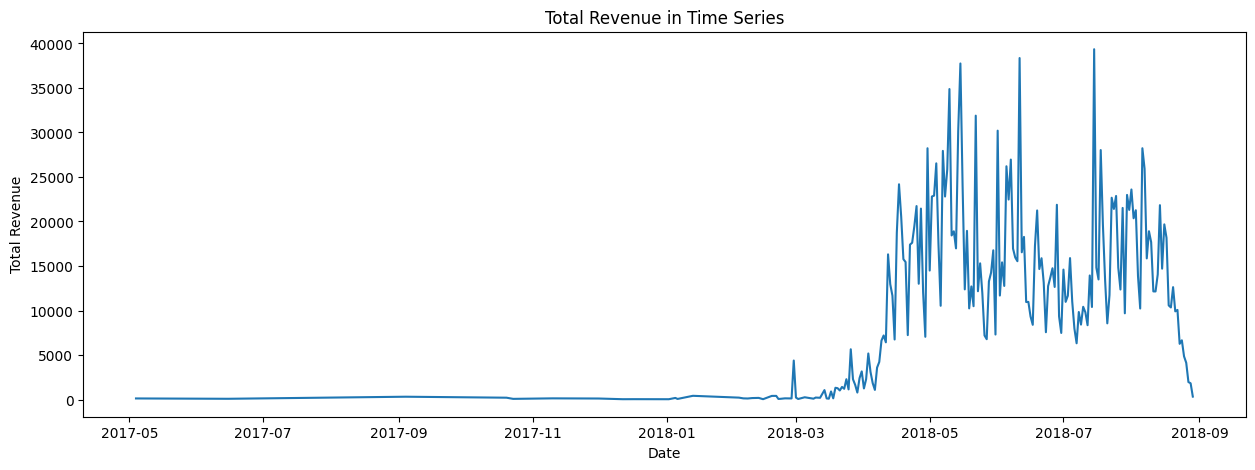

In [68]:
# perform visualization of total revenue in time series
order_df["order_purchase_timestamp"] = pd.to_datetime(order_df["order_purchase_timestamp"])
order_df["order_purchase_date"] = order_df["order_purchase_timestamp"].dt.date
order_df["order_purchase_month"] = order_df["order_purchase_timestamp"].dt.to_period("M")
order_df["order_purchase_year"] = order_df["order_purchase_timestamp"].dt.to_period("Y")

# Group by order_purchase_date and order_purchase_year
grouped_df = order_df.groupby(["order_purchase_date", "order_purchase_year"]).agg({"payment_value": "sum"}).reset_index()
colors = sns.color_palette("pastel", as_cmap=True)

plt.figure(figsize=(15, 5))
sns.lineplot(data=grouped_df, x="order_purchase_date", y="payment_value")
plt.title("Total Revenue in Time Series")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

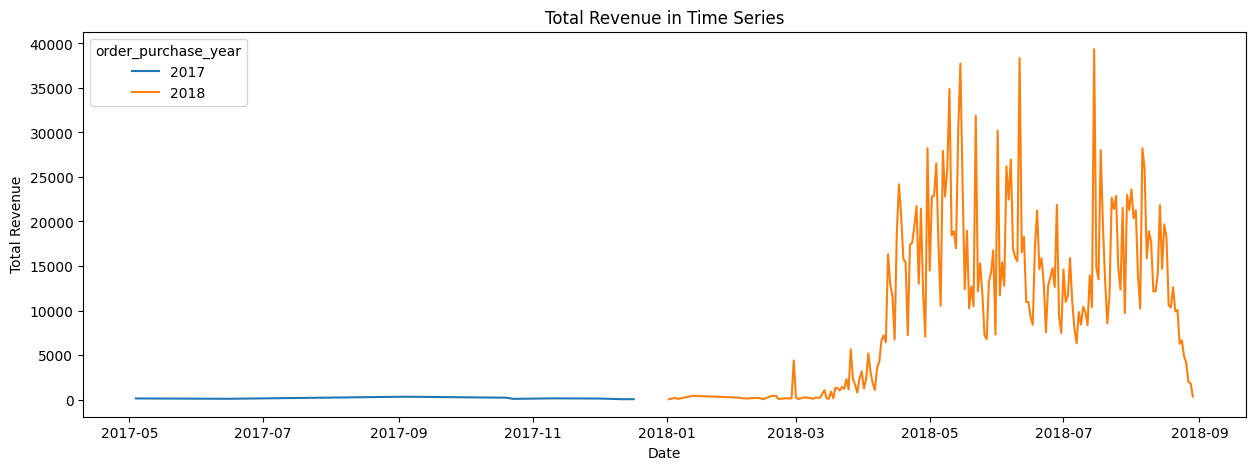

In [69]:
# perform visualization of total revenue in time series

order_df["order_purchase_timestamp"] = pd.to_datetime(order_df["order_purchase_timestamp"])
order_df["order_purchase_date"] = order_df["order_purchase_timestamp"].dt.date
order_df["order_purchase_month"] = order_df["order_purchase_timestamp"].dt.to_period("M")
order_df["order_purchase_year"] = order_df["order_purchase_timestamp"].dt.to_period("Y")

# Group by order_purchase_date and order_purchase_year
grouped_df = order_df.groupby(["order_purchase_date", "order_purchase_year"]).agg({"payment_value": "sum"}).reset_index()

plt.figure(figsize=(15, 5))
sns.lineplot(data=grouped_df, x="order_purchase_date", y="payment_value", hue="order_purchase_year")
plt.title("Total Revenue in Time Series")
plt.xlabel("Date")
plt.ylabel("Total Revenue")
plt.show()

### Pertanyaan 2:

2. What Item Sales the Most and the least?

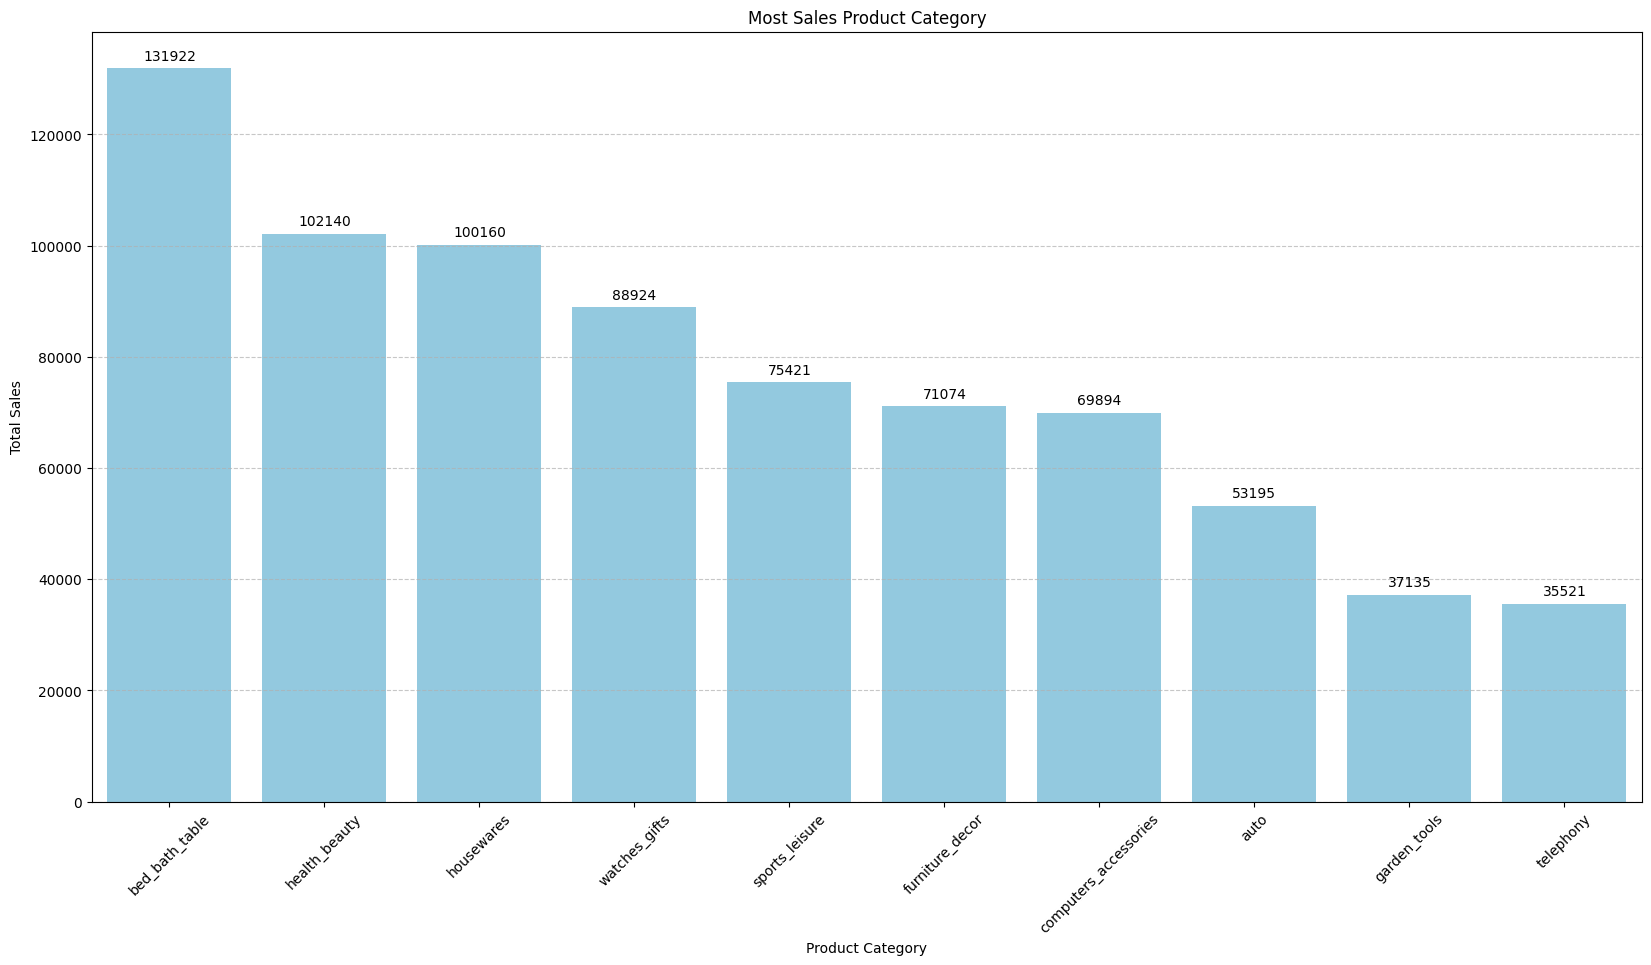

In [70]:
grouped_df = all_df.groupby("product_category_name_english").agg({"order_id": "count"}).reset_index()
grouped_df = grouped_df.sort_values("order_id", ascending=False).head(10)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=grouped_df, x="product_category_name_english", y="order_id", color="skyblue")
plt.title("Most Sales Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add annotation
for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

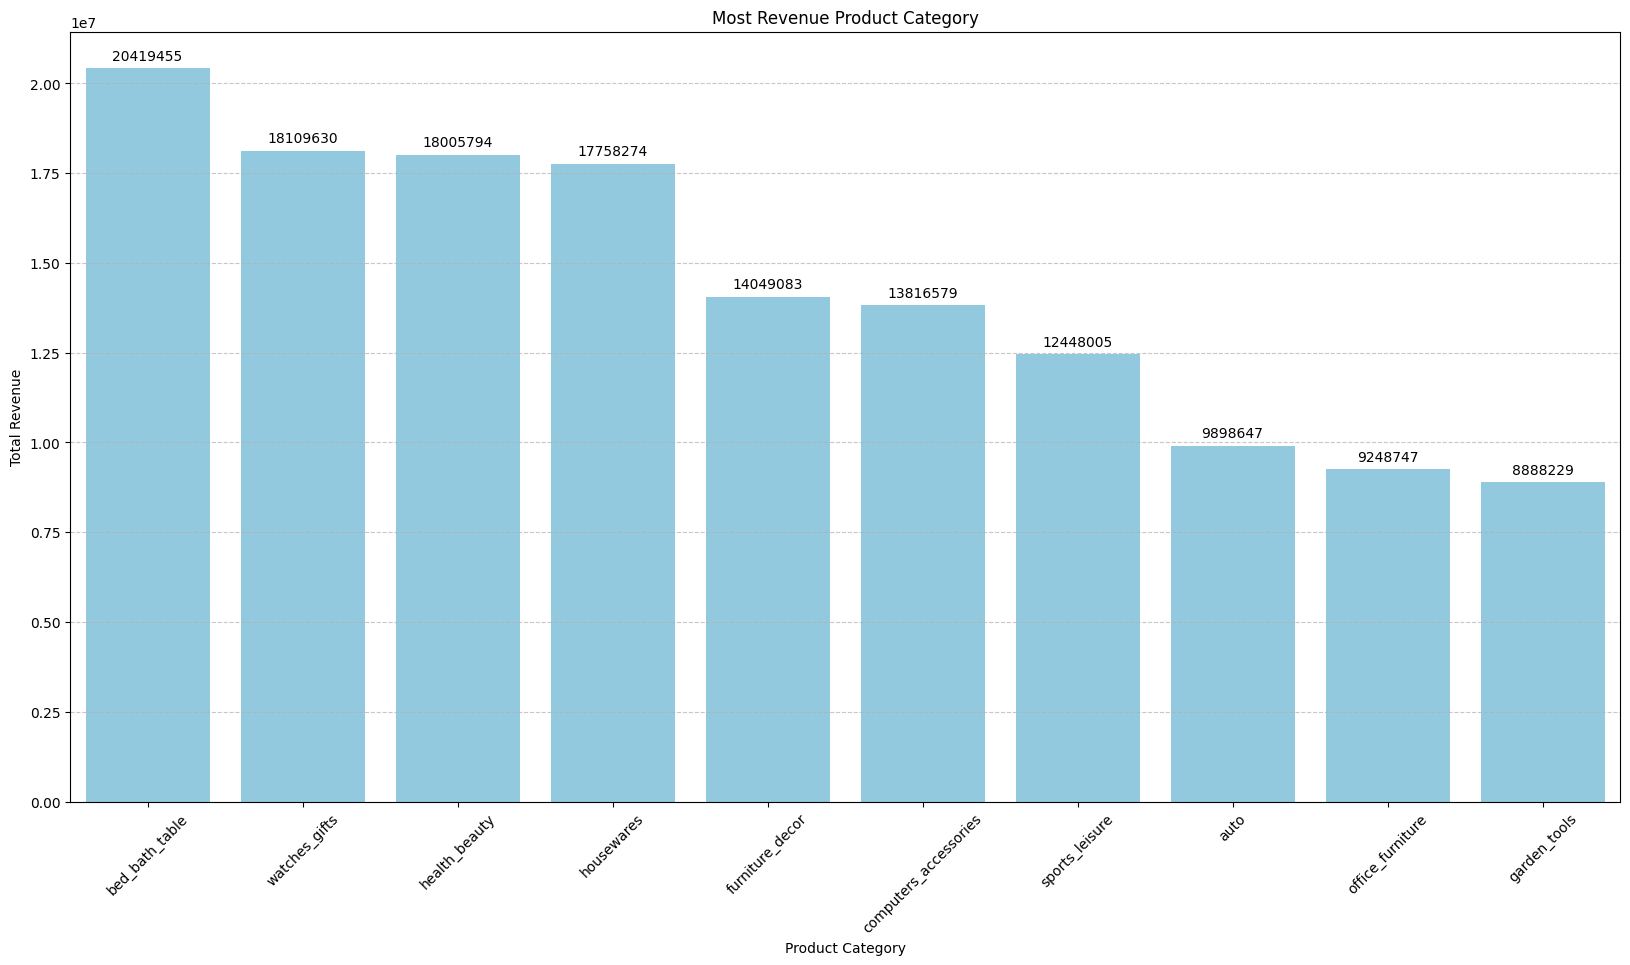

In [71]:
grouped_df = all_df.groupby("product_category_name_english").agg({"payment_value": "sum"}).reset_index()
grouped_df = grouped_df.sort_values("payment_value", ascending=False).head(10)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=grouped_df, x="product_category_name_english", y="payment_value", color="skyblue")
plt.title("Most Revenue Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add annotation
for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
plt.show()

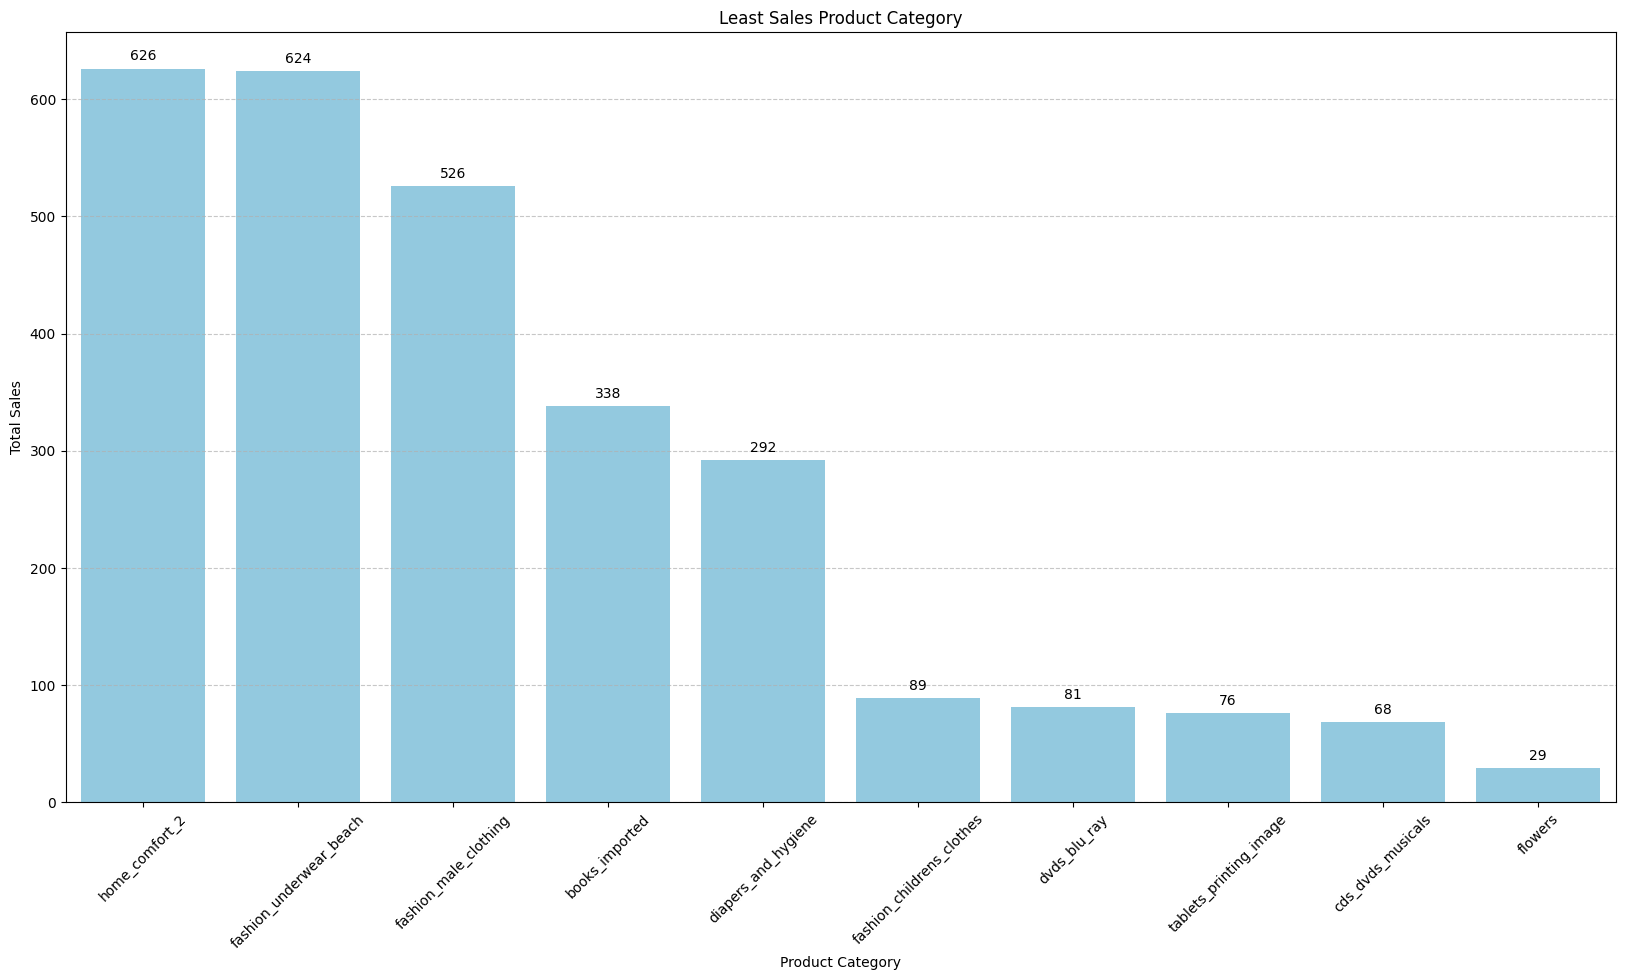

In [72]:
grouped_df = all_df.groupby("product_category_name_english").agg({"order_id": "count"}).reset_index()
grouped_df = grouped_df.sort_values("order_id", ascending=False).tail(10)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=grouped_df, x="product_category_name_english", y="order_id", color="skyblue")
plt.title("Least Sales Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Sales")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add annotation
for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')

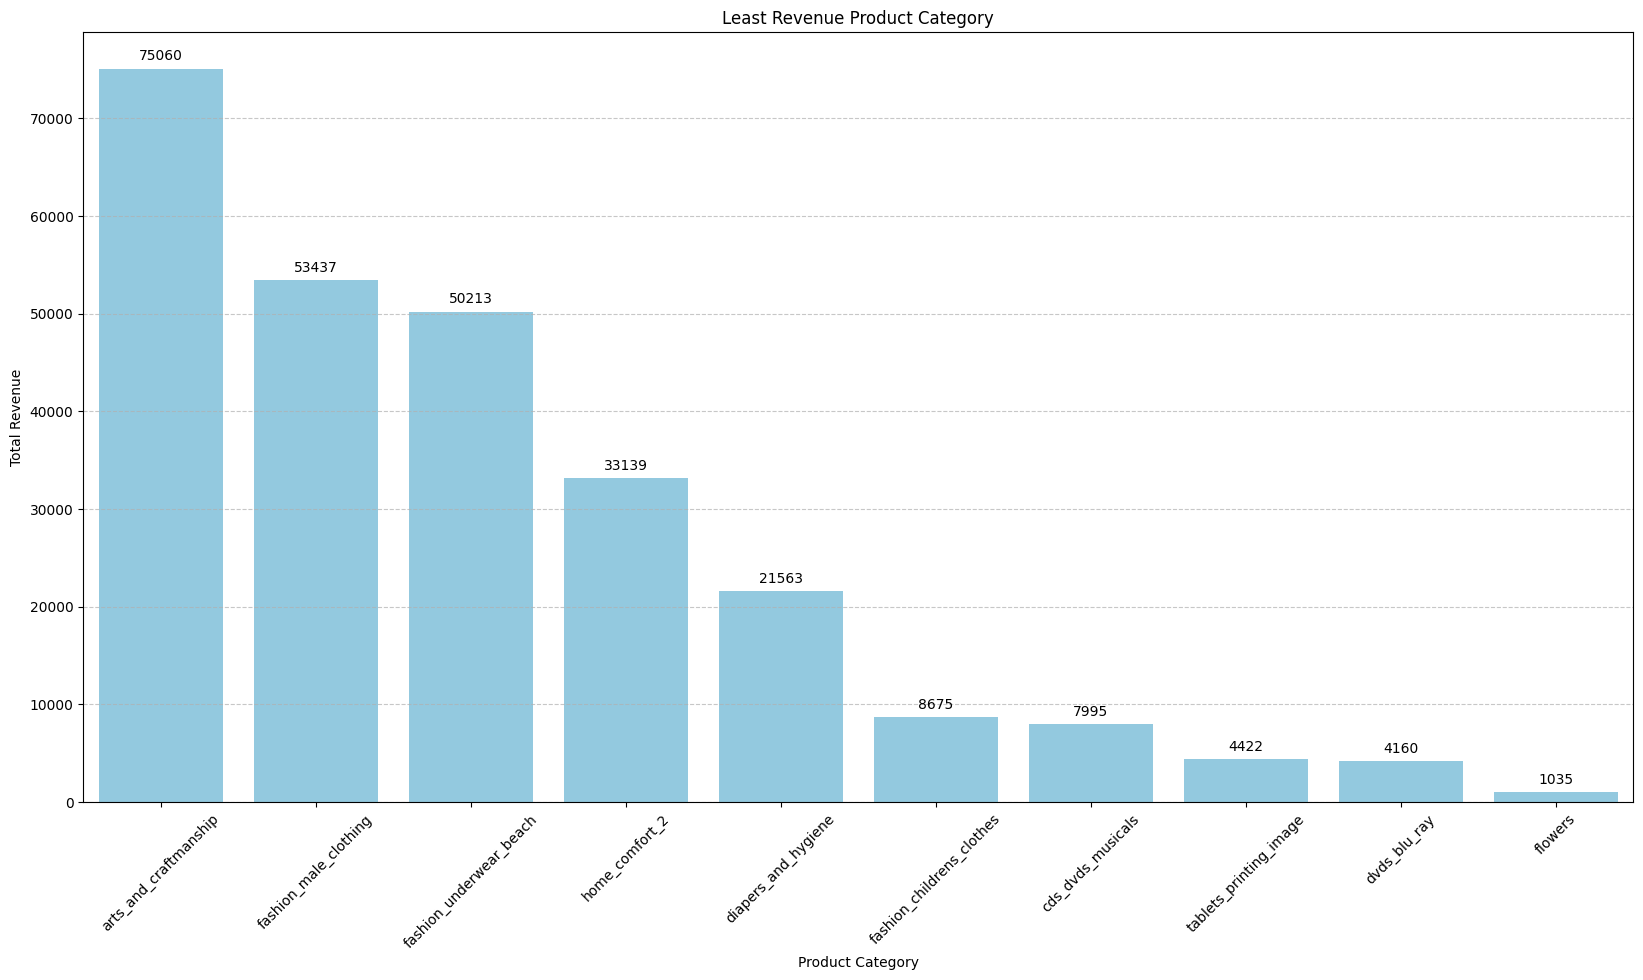

In [73]:
grouped_df = all_df.groupby("product_category_name_english").agg({"payment_value": "sum"}).reset_index()
grouped_df = grouped_df.sort_values("payment_value", ascending=False).tail(10)

plt.figure(figsize=(20, 10))
ax = sns.barplot(data=grouped_df, x="product_category_name_english", y="payment_value", color="skyblue")
plt.title("Least Revenue Product Category")
plt.xlabel("Product Category")
plt.ylabel("Total Revenue")
plt.xticks(rotation=45)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# add annotation
for p in ax.patches:
    height = p.get_height()
    if height > 0:  
        ax.annotate(f'{int(height)}', 
                    (p.get_x() + p.get_width() / 2., height), 
                    ha='center', va='center', 
                    xytext=(0, 9), 
                    textcoords='offset points')
plt.show()

### Pertanyaan 3:

3. How is the performance of our packaging time and shipping time?

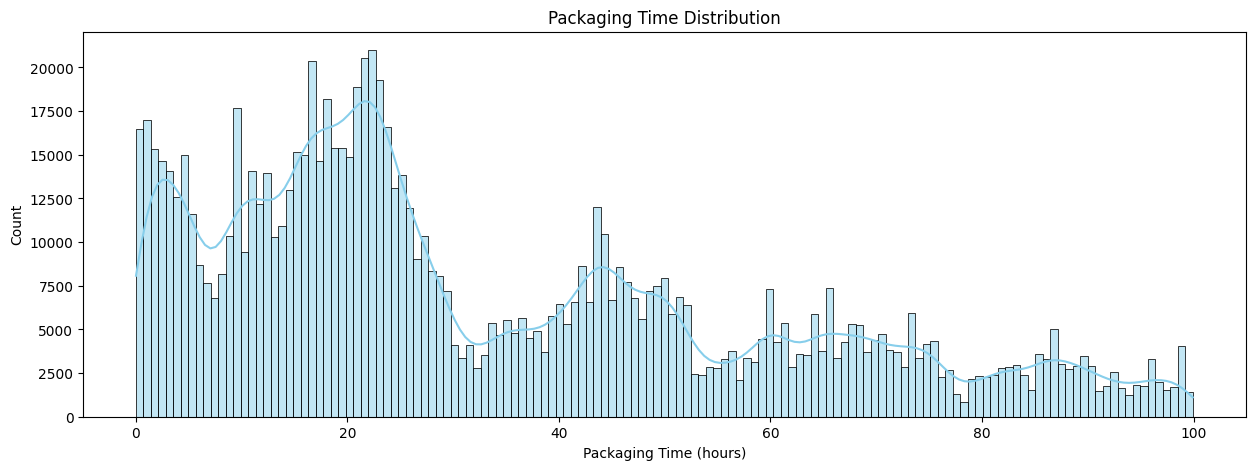

In [74]:
# transform packaging_time to hours
all_df["packaging_time_hours"] = all_df["packaging_time"].dt.total_seconds() / 3600

# remove outliers to get better visualization
all_df = all_df[all_df["packaging_time_hours"] < 100]

plt.figure(figsize=(15, 5))
sns.histplot(data=all_df, x="packaging_time_hours", kde=True, color="skyblue")
plt.title("Packaging Time Distribution")
plt.xlabel("Packaging Time (hours)")
plt.ylabel("Count")
plt.show()

C:\Users\salma\AppData\Local\Temp\ipykernel_17220\1218989525.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  all_df.loc[:, "shipping_time_hours"] = all_df["shipping_time"].dt.total_seconds() / 3600


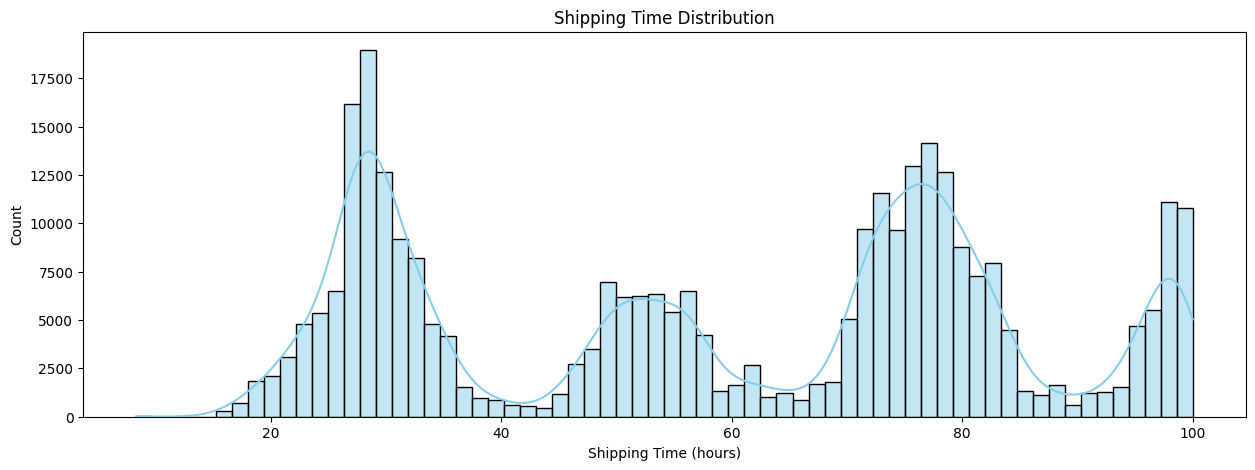

In [75]:
# transform shipping_time to hours
all_df.loc[:, "shipping_time_hours"] = all_df["shipping_time"].dt.total_seconds() / 3600

# remove outliers to get better visualization
all_df = all_df[all_df["shipping_time_hours"] < 100]

plt.figure(figsize=(15, 5))
sns.histplot(data=all_df, x="shipping_time_hours", kde=True, color="skyblue")
plt.title("Shipping Time Distribution")
plt.xlabel("Shipping Time (hours)")
plt.ylabel("Count")
plt.show()

**Insight:**
- From this visualization we can answer the question from the beginning of the cell
- We can see the trend goes up in the end of the year
- We know top 10 the most and the least selling item from the figure that we plot
- we also know how is the distribution age of our customer, top city and state that purchase product the most, and the gender that surprisingly balanced  

## Analisis Lanjutan (Opsional)

## RFM Analysis

#### Recency

In [76]:
# perform rfm analysis
all_df["order_purchase_date"] = all_df["order_purchase_timestamp"].dt.date
all_df["order_purchase_month"] = all_df["order_purchase_timestamp"].dt.to_period("M")
all_df["order_purchase_year"] = all_df["order_purchase_timestamp"].dt.to_period("Y")

# calculate recency
current_date = all_df["order_purchase_date"].max()
recency_df = all_df.groupby("customer_unique_id").agg({"order_purchase_date": "max"}).reset_index()
recency_df["recency"] = current_date - recency_df["order_purchase_date"]
recency_df["recency"] = recency_df["recency"].apply(lambda x: x.days)

# calculate frequency
frequency_df = all_df.groupby("customer_unique_id").agg({"order_id": "count"}).reset_index()
frequency_df.rename(columns={"order_id": "frequency"}, inplace=True)

# calculate monetary
monetary_df = all_df.groupby("customer_unique_id").agg({"payment_value": "sum"}).reset_index()
monetary_df.rename(columns={"payment_value": "monetary"}, inplace=True)

#### Frequency

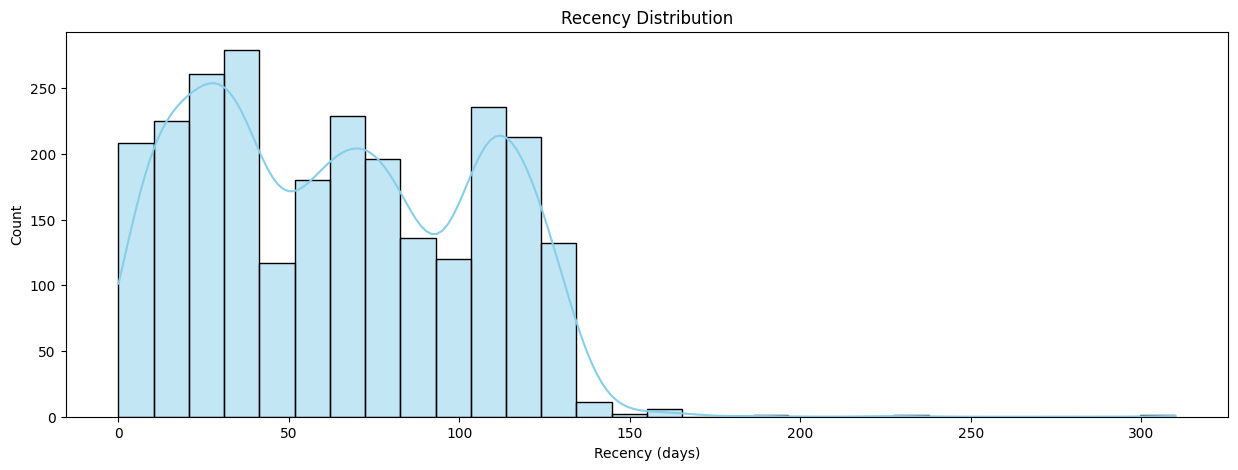

In [77]:
# perform visualization of recency
plt.figure(figsize=(15, 5))
sns.histplot(data=recency_df, x="recency", kde=True, color="skyblue")
plt.title("Recency Distribution")
plt.xlabel("Recency (days)")
plt.ylabel("Count")
plt.show()

#### Frequency

Text(0, 0.5, 'Count')

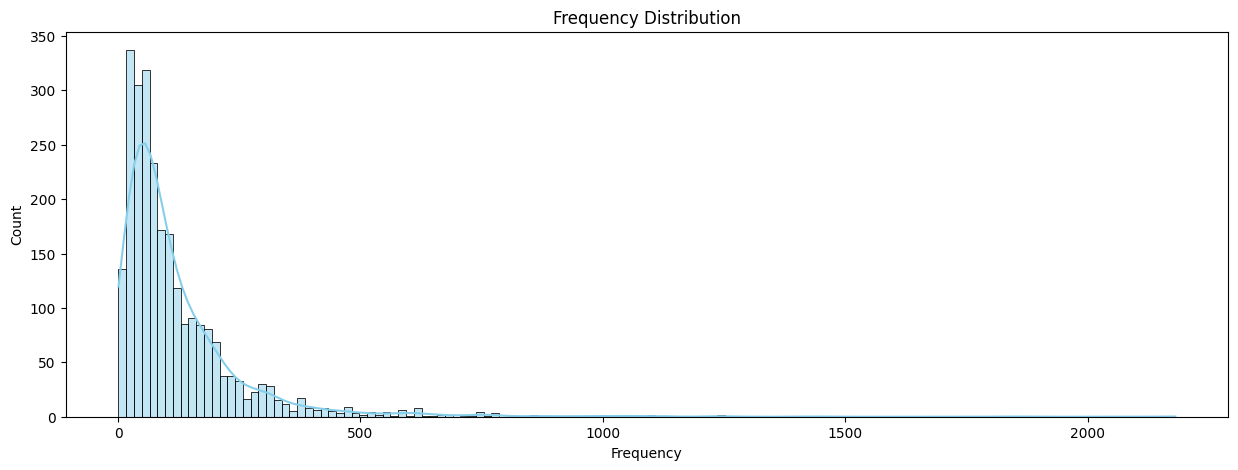

In [78]:
# perform visualization of frequency
plt.figure(figsize=(15, 5))
sns.histplot(data=frequency_df, x="frequency", kde=True, color="skyblue")
plt.title("Frequency Distribution")
plt.xlabel("Frequency")
plt.ylabel("Count")

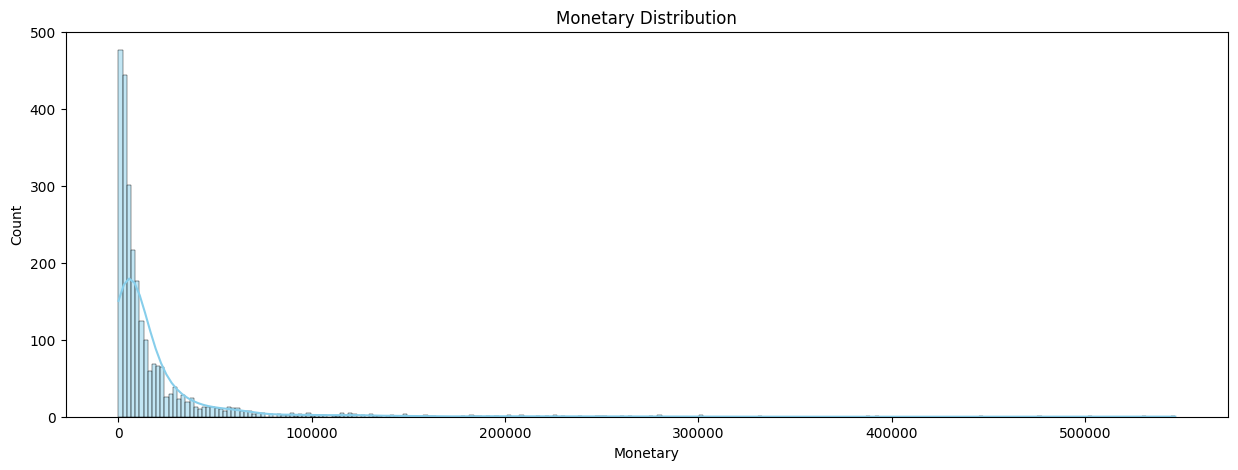

In [79]:
# perform visualization of monetary
plt.figure(figsize=(15, 5))
sns.histplot(data=monetary_df, x="monetary", kde=True, color="skyblue")
plt.title("Monetary Distribution")
plt.xlabel("Monetary")
plt.ylabel("Count")
plt.show()

**Insight:**
- Recency tell us about the number of days since the last purchase.
- Frequency tell us about how frequent is a single user buy our product
- Monetary tell us about total spending of a single user

## Geospatial Analysis

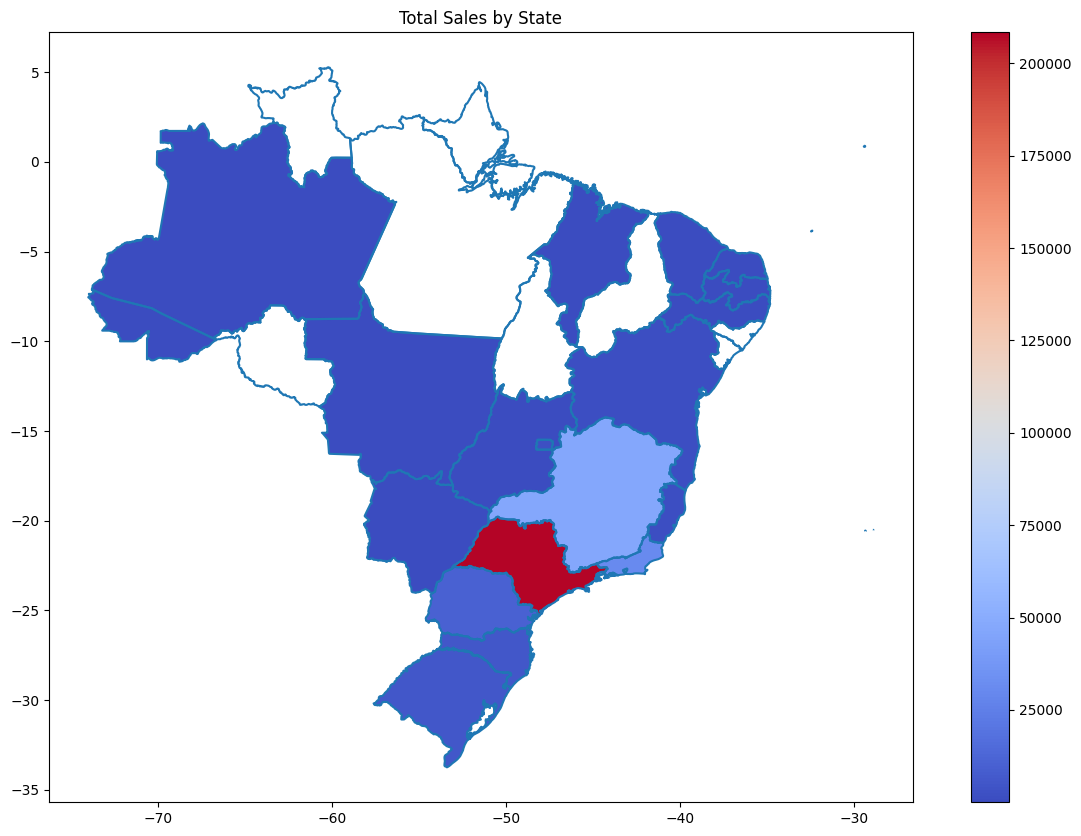

In [80]:
# Group by geolocation_state
brazil_map = gpd.read_file("br_shp/br.shp")
brazil_map['id'] = brazil_map['id'].str.replace('BR', '')
grouped_df = all_df.groupby("geolocation_state").agg({"order_id": "count"}).reset_index()

# Merge Brazil map with grouped_df
brazil_map = brazil_map.merge(grouped_df, left_on="id", right_on="geolocation_state", how="left")

# Plot Brazil map
fig, ax = plt.subplots(1, 1, figsize=(15, 10))
brazil_map.boundary.plot(ax = ax)
brazil_map.plot(column="order_id", cmap="coolwarm", legend=True, ax=ax)
plt.title("Total Sales by State")
plt.show()

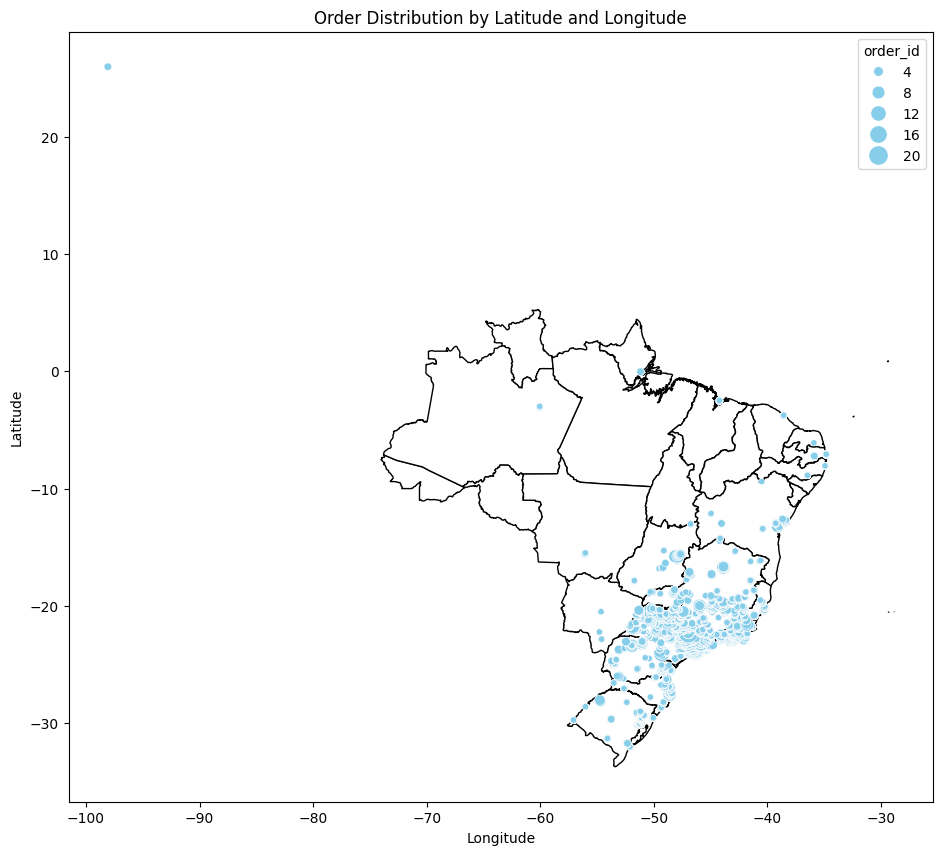

In [81]:
brazil_map = gpd.read_file("br_shp/br.shp")
grouped_df = all_df.groupby(["geolocation_lat", "geolocation_lng"]).agg({"order_id": "count"}).reset_index()

fig, ax = plt.subplots(figsize=(15, 10))
brazil_map.plot(ax=ax, color='white', edgecolor='black')
sns.scatterplot(data=grouped_df, x="geolocation_lng", y="geolocation_lat", size="order_id", sizes=(20, 200), color="skyblue", ax=ax)
plt.title("Order Distribution by Latitude and Longitude")
plt.xlabel("Longitude")
plt.ylabel("Latitude")
plt.show()

**Insight:**
- the figure actually tell us about the buyers of each state of the Brazil
- the more warm (red) the states the more spend they do, more dots means more buyers there

## Conclusion

- We now can see the trend of the data in the year 2017 is stagnan and goes up in year 2018
- We now know that housewares, health beauty, bed bath table, sports leisure, and furniture decor is the top 5 most sales item but the most item that gives the revenue is furniture decor, health beauty, bed bath table, housewares, and watches gifts. costruction tools, books imported, party supplies, fashion childrens clothes, and diapers and the hygiene is the the top 5 least sales item but books imported, party supplies, fashion childrens clothes, diapers and hygiene, and the market_place is the least item that gives revenue	
- The performance of the packaging time and shipping time is very good because most the visualization shows right skew, means that most of the packaging and the shipping were doing so fast
- from RFM analysis, we know that most of our customer not do repeat buy and each custumer spend small amount of money 
- from geospatial analysis, we know that most of our customer comes from Rio de Jeneiro

In [82]:
# export all_df to csv
all_df.to_csv("data/all_df.csv", index=False)